# Routing

### baseline qasmbench-large

In [11]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/baselines/results/qasmbench-large"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv"]
columns_to_mean = ["sherbrooke_swaps_trivial", "sherbrooke_depth_trivial"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)

Error processing cirq.csv: Could not convert ['148error63166649421796224104error3864541465433689914419010672error2060'
 '263error9339207410039112207152error66958049361524211197344188100error4250'] to numeric

Preview of the data:
  source_file  sherbrooke_swaps_trivial  sherbrooke_depth_trivial
0   sabre.csv                705.727273               1068.136364
1    qmap.csv                706.590909               1021.500000
2  pytket.csv                794.863636               1140.090909


In [1]:
import pandas as pd

df = pd.read_csv("/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/llm_qasm_large_ibm_sherbrooke_trivial.csv")
mean_swap = df["swap_count"].mean()
mean_depth = df["final_depth"].mean()

print("qlosure")
print("swaps : ", mean_swap)
print("mean depth : ", mean_depth)

qlosure
swaps :  447.1904761904762
mean depth :  554.8095238095239


In [ ]:
import pandas as pd

df = pd.read_csv("/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/llm_queko16_ibm_sherbrooke_trivial.csv")
mean_swap = df["swap_count"].mean()
mean_depth = df["final_depth"].mean()

print("llm")
print("swaps : ", mean_swap)
print("mean depth : ", mean_depth)

qlosure
swaps :  921.7777777777778
mean depth :  1342.111111111111


In [ ]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/llm_queko16_ibm_sherbrooke_trivial.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}

qlosure_path = "/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/qlosure_queko16_ibm_sherbrooke_trivial.csv"
try:
    df_qlosure = pd.read_csv(qlosure_path)
    baselines["qlosure"] = {
        "swaps": df_qlosure["swap_count"].mean(),
        "depth": df_qlosure["final_depth"].mean()
    }
except Exception as e:
    print(f"Error reading Qlosure file: {e}")

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-16qbt"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["sherbrooke_swaps_trivial"].mean(),
                "depth": df["sherbrooke_depth_trivial"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

# 4. Display Results
if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    
    print(results_df.to_string(index=False, float_format="%.2f"))
    
    print("\n--- Average Overall Improvement  ---")
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

### baseline queko 16qbt

In [6]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-16qbt"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv"]
columns_to_mean = ["sherbrooke_swaps_trivial", "sherbrooke_depth_trivial"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
  source_file  sherbrooke_swaps_trivial  sherbrooke_depth_trivial
0   sabre.csv                953.100000               1323.911111
1    cirq.csv               1074.388889               2042.233333
2    qmap.csv               1265.177778               1420.700000
3  pytket.csv               1176.244444               1483.433333


In [29]:
import pandas as pd

df = pd.read_csv("/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/qlosure_queko16_ibm_sherbrooke_trivial.csv")
mean_swap = df["swap_count"].mean()
mean_depth = df["final_depth"].mean()
print("qlosure")
print("swaps : ", mean_swap)
print("mean depth : ", mean_depth)

qlosure
swaps :  917.1777777777778
mean depth :  1318.3111111111111


In [30]:
import pandas as pd

df = pd.read_csv("/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/llm_queko16_ibm_sherbrooke_trivial.csv")
mean_swap = df["swap_count"].mean()
mean_depth = df["final_depth"].mean()
print("llm")
print("swaps : ", mean_swap)
print("mean depth : ", mean_depth)

llm
swaps :  916.1333333333333
mean depth :  1312.6888888888889


In [31]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/llm_queko16_ibm_sherbrooke_trivial.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}

qlosure_path = "/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/qlosure_queko16_ibm_sherbrooke_trivial.csv"
try:
    df_qlosure = pd.read_csv(qlosure_path)
    baselines["qlosure"] = {
        "swaps": df_qlosure["swap_count"].mean(),
        "depth": df_qlosure["final_depth"].mean()
    }
except Exception as e:
    print(f"Error reading Qlosure file: {e}")

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-16qbt"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["sherbrooke_swaps_trivial"].mean(),
                "depth": df["sherbrooke_depth_trivial"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

# 4. Display Results
if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    
    print(results_df.to_string(index=False, float_format="%.2f"))
    
    print("\n--- Average Overall Improvement  ---")
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

 Method  Swap Improvement (%)  Depth Improvement (%)
qlosure                  0.11                   0.43
  sabre                  3.88                   0.85
   cirq                 14.73                  35.72
   qmap                 27.59                   7.60
 pytket                 22.11                  11.51

--- Average Overall Improvement  ---
Average Swap Improvement:  13.68%
Average Depth Improvement: 11.22%


### queko 54qbt

In [36]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-54qbt"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv"]
columns_to_mean = ["sherbrooke_swaps_trivial", "sherbrooke_depth_trivial"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)

Error processing pytket.csv: Could not convert ['1415910811741314581109781250362341416616391289011331470110407140946578timeout11590676413346987521588845113531142413679708914611825515307100111018811470216485711257575591149454768784362693658790timeout248027973905142164254993812491147647481108241386725721462410864987014605119225594880120291477656992366462420415614timeout428613618701013680136734829144772735683212189444779499443985410637353355615806383712933'
 '810661614410863267837305372479619362149064672378601184283867timeout65033907776357651113502670216906775941248666466694686098585667711169504075604342645630915365220554375116timeout12671473228581102399591678818575457665168564141684146234592588017048316851891151896234991287253011473083timeout24677741429682888293254090671469403767972293473055885807619320613193344022927759'] to numeric

Preview of the data:
  source_file  sherbrooke_swaps_trivial  sherbrooke_depth_trivial
0   sabre.csv               7876.455556               4042.300000
1 

In [37]:
import pandas as pd

df = pd.read_csv("/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/qlosure_queko54_ibm_sherbrooke_trivial.csv")
mean_swap = df["swap_count"].mean()
mean_depth = df["final_depth"].mean()
print("qlosure")
print("swaps : ", mean_swap)
print("mean depth : ", mean_depth)

qlosure
swaps :  6942.644444444444
mean depth :  3214.6111111111113


In [38]:
import pandas as pd

df = pd.read_csv("/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/llm_queko54_ibm_sherbrooke_trivial.csv")
mean_swap = df["swap_count"].mean()
mean_depth = df["final_depth"].mean()
print("llm")
print("swaps : ", mean_swap)
print("mean depth : ", mean_depth)

llm
swaps :  6977.6
mean depth :  3173.6111111111113


In [40]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/llm_queko54_ibm_sherbrooke_trivial.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}

qlosure_path = "/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/qlosure_queko54_ibm_sherbrooke_trivial.csv"
try:
    df_qlosure = pd.read_csv(qlosure_path)
    baselines["qlosure"] = {
        "swaps": df_qlosure["swap_count"].mean(),
        "depth": df_qlosure["final_depth"].mean()
    }
except Exception as e:
    print(f"Error reading Qlosure file: {e}")

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-54qbt"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["sherbrooke_swaps_trivial"].mean(),
                "depth": df["sherbrooke_depth_trivial"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

# 4. Display Results
if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    
    print(results_df.to_string(index=False, float_format="%.2f"))
    
    print("\n--- Average Overall Improvement  ---")
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

Error processing pytket.csv: Could not convert string '1415910811741314581109781250362341416616391289011331470110407140946578timeout11590676413346987521588845113531142413679708914611825515307100111018811470216485711257575591149454768784362693658790timeout248027973905142164254993812491147647481108241386725721462410864987014605119225594880120291477656992366462420415614timeout428613618701013680136734829144772735683212189444779499443985410637353355615806383712933' to numeric
 Method  Swap Improvement (%)  Depth Improvement (%)
qlosure                 -0.50                   1.28
  sabre                 11.41                  21.49
   cirq                 15.14                  23.88
   qmap                 43.85                   9.23

--- Average Overall Improvement  ---
Average Swap Improvement:  17.47%
Average Depth Improvement: 13.97%


### queko 81qbt

In [4]:
import pandas as pd
import os

my_file_path = "/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/llm_queko81_ibm_sherbrooke_trivial.csv"
my_df = pd.read_csv(my_file_path)
mean_swap = my_df["swap_count"].mean()
mean_depth = my_df["final_depth"].mean()

print(f"LLM -> Swaps: {mean_swap:.2f} | Depth: {mean_depth:.2f}\n")

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-81qbt"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv", "Qlosure.csv"]
columns_to_mean = ["sherbrooke_swaps_trivial", "sherbrooke_depth_trivial"]

summary_data = []

print("Processing baseline files...")
for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]

summary_df["outperform_swap_rate_%"] = ((summary_df["sherbrooke_swaps_trivial"] - mean_swap) / summary_df["sherbrooke_swaps_trivial"]) * 100
summary_df["outperform_depth_rate_%"] = ((summary_df["sherbrooke_depth_trivial"] - mean_depth) / summary_df["sherbrooke_depth_trivial"]) * 100

summary_df["outperform_swap_rate_%"] = summary_df["outperform_swap_rate_%"].round(2)
summary_df["outperform_depth_rate_%"] = summary_df["outperform_depth_rate_%"].round(2)

print("\n--- Final Outperform Comparison ---")
print(summary_df)

LLM -> Swaps: 14560.94 | Depth: 4609.74

Processing baseline files...
Error processing pytket.csv: Could not convert ['26430188522828787302840629871204861660949951282223732176492184330723timeout121675137124142743643614118312913615825545894716607130953208923731305347850807320525480731075158832580278351536827241406818247192484415120651470429179141188082183532667816669114151798915210805327495timeout11538322724251805380139916timeout208892512299102305451112386144232180619689779217177timeout26905238111875910885191353013514605152272214025469248701569432353'
 '1074382081192232511193212177851868401882528495786682915712744timeout461419285305114631873162712849153081035034916727522313785945712677312932848695186912552667610790327960571169117317823835516754724605612557586630207861109616795470675996381324011404timeout4863139171619312330134079timeout8601106283968968719711032717418822849831867092timeout110729950780345147546124365979614592561082110162624813204'] to numeric

--- Final Outperform Comparis

### plots queko-16qbt

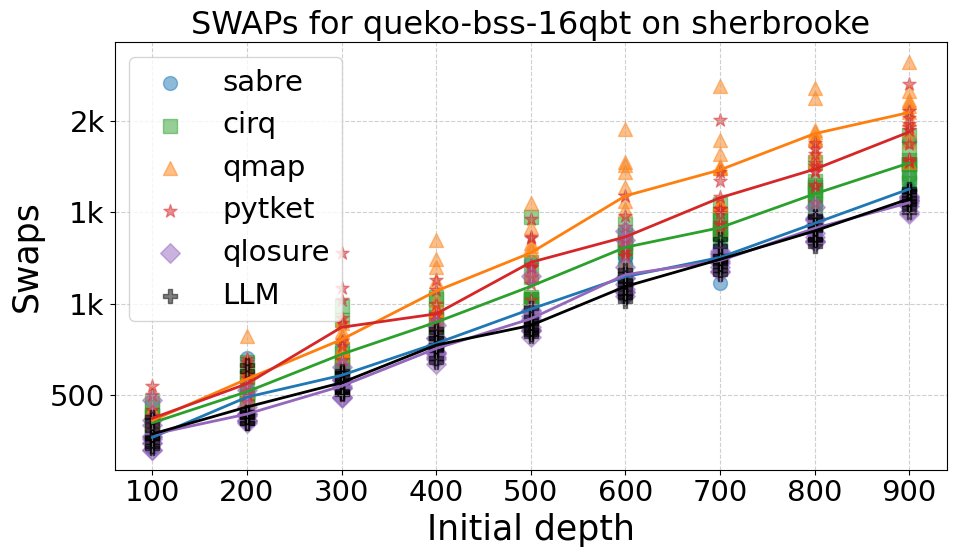

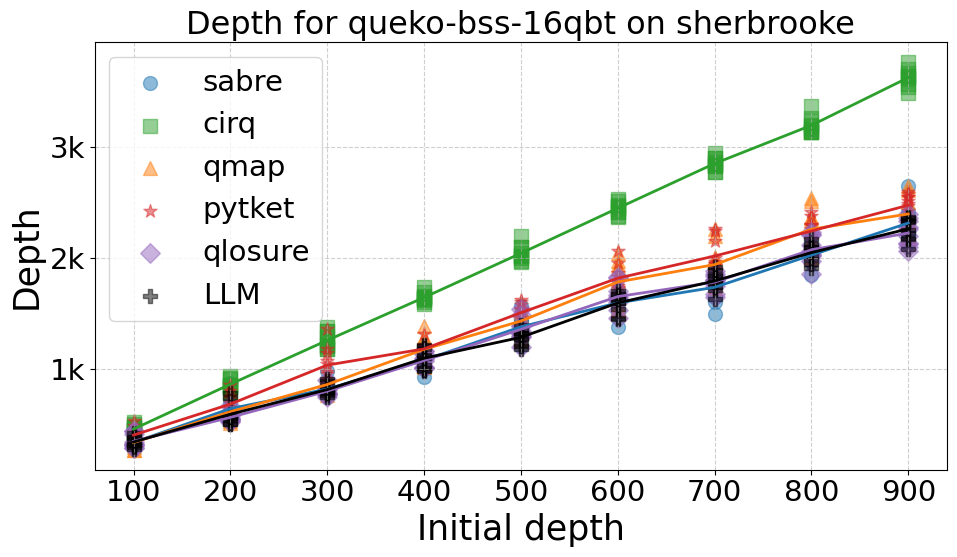

In [35]:
import os
import sys
import matplotlib.pyplot as plt
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-16qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"./baselines/results/{BENCHMARK}/sabre.csv",
    "cirq": f"./baselines/results/{BENCHMARK}/cirq.csv",
    "qmap": f"./baselines/results/{BENCHMARK}/qmap.csv",
    "pytket": f"./baselines/results/{BENCHMARK}/pytket.csv",
    "qlosure": f"/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/qlosure_queko16_ibm_sherbrooke_trivial.csv",
    "LLM" : f"/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/llm_queko16_ibm_sherbrooke_trivial.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path) if name in ["qlosure", "LLM"] else group_by_initial_depth_baseline(
            path, backend=plot_backend, init_mapping_method="trivial")
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

### plots queko-54qbt

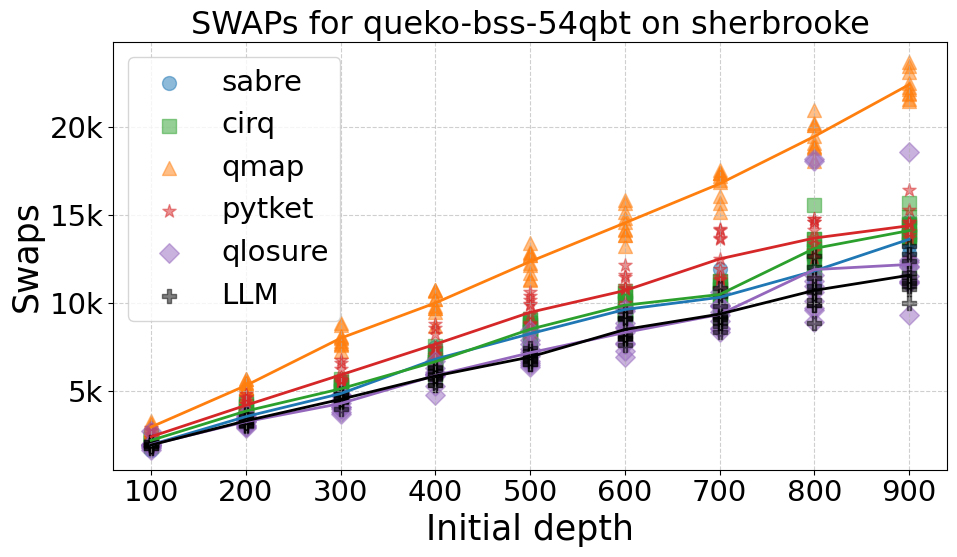

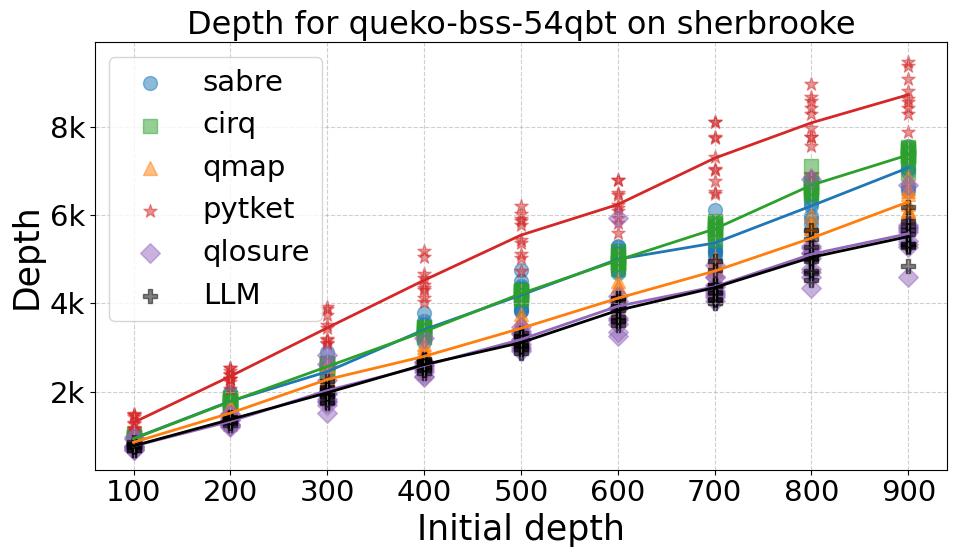

In [28]:
import os
import sys
import matplotlib.pyplot as plt
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-54qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"./baselines/results/{BENCHMARK}/sabre.csv",
    "cirq": f"./baselines/results/{BENCHMARK}/cirq.csv",
    "qmap": f"./baselines/results/{BENCHMARK}/qmap.csv",
    "pytket": f"./baselines/results/{BENCHMARK}/pytket.csv",
    "qlosure": f"/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-54qbt/Qlosure.csv",
    "LLM" : f"/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/llm_queko54_ibm_sherbrooke_trivial.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path) if name in ["LLM"] else group_by_initial_depth_baseline(
            path, backend=plot_backend, init_mapping_method="trivial")
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

# initial mapping

In [1]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/baselines/results/qasmbench-large"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv"]
columns_to_mean = ["sherbrooke_swaps_default", "sherbrooke_depth_default"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
  source_file  sherbrooke_swaps_default  sherbrooke_depth_default
0   sabre.csv                577.772727               1066.909091
1    cirq.csv                750.045455               1153.318182
2    qmap.csv                507.409091                925.818182
3  pytket.csv                587.954545               1028.772727


In [2]:
import pandas as pd

df = pd.read_csv("/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/init_mapping_llm_qasm_bench_ibm_sherbrooke_trivial.csv")
mean_swap = df["swap_count"].mean()
mean_depth = df["final_depth"].mean()

print("qlosure")
print("swaps : ", mean_swap)
print("mean depth : ", mean_depth)

qlosure
swaps :  512.0909090909091
mean depth :  918.3181818181819


In [5]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/init_mapping_llm_qasm_bench_ibm_sherbrooke_trivial.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}
directory = "/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-16qbt"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["sherbrooke_swaps_default"].mean(),
                "depth": df["sherbrooke_depth_default"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

# 4. Display Results
if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    
    print(results_df.to_string(index=False, float_format="%.2f"))
    
    print("\n--- Average Overall Improvement  ---")
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

Method  Swap Improvement (%)  Depth Improvement (%)
 sabre                 15.23                   6.44
  cirq                 45.23                  53.58
  qmap                 59.52                  35.36
pytket                 51.04                  39.08

--- Average Overall Improvement  ---
Average Swap Improvement:  42.76%
Average Depth Improvement: 33.62%


### queko 16qbt

In [9]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-16qbt/"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv", "Qlosure.csv"]
columns_to_mean = ["sherbrooke_swaps_default", "sherbrooke_depth_default"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
   source_file  sherbrooke_swaps_default  sherbrooke_depth_default
0    sabre.csv                604.111111                981.522222
1     cirq.csv                934.955556               1978.333333
2     qmap.csv               1265.177778               1420.700000
3   pytket.csv               1045.944444               1507.411111
4  Qlosure.csv                564.577778                929.933333


In [1]:
import pandas as pd

df = pd.read_csv("/home/jmsb00nd/Documents/auto-heuristics/results/init_mapping_llm_queko_bss_16qbt_ibm_sherbrooke.csv")
mean_swap = df["swap_count"].mean()
mean_depth = df["final_depth"].mean()

print("llm")
print("swaps : ", mean_swap)
print("mean depth : ", mean_depth)

llm
swaps :  589.5888888888888
mean depth :  986.2777777777778


In [1]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/results/init_mapping_llm_queko_bss_16qbt_ibm_sherbrooke.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}
directory = "/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-16qbt"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv", "Qlosure.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["sherbrooke_swaps_default"].mean(),
                "depth": df["sherbrooke_depth_default"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

# 4. Display Results
if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    
    print(results_df.to_string(index=False, float_format="%.2f"))
    
    print("\n--- Average Overall Improvement  ---")
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

 Method  Swap Improvement (%)  Depth Improvement (%)
  sabre                  2.40                  -0.48
   cirq                 36.94                  50.15
   qmap                 53.40                  30.58
 pytket                 43.63                  34.57
Qlosure                 -4.43                  -6.06

--- Average Overall Improvement  ---
Average Swap Improvement:  26.39%
Average Depth Improvement: 21.75%


### queko 54

In [11]:
import pandas as pd

df = pd.read_csv("/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/init_mapping_llm_queko-bss-54qbt_ibm_sherbrooke_trivial.csv")
mean_swap = df["swap_count"].mean()
mean_depth = df["final_depth"].mean()

print("llm")
print("swaps : ", mean_swap)
print("mean depth : ", mean_depth)

llm
swaps :  5559.766666666666
mean depth :  2683.088888888889


In [35]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-54qbt"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv", "Qlosure.csv"]
columns_to_mean = ["sherbrooke_swaps_default", "sherbrooke_depth_default"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)

Error processing pytket.csv: Could not convert ['1269798327203155501141512305540713245144701728114044309840716091646316015110805032147119126181881151162814498timeout7636130786814160181113788031161724336631127926625118885355102064326926279907469233522204205123624636928613888145497169130461383724121300210276timeout1539113145489873112193timeout501621334173208260285481383113048741814376122984701139982379646689014417839111208111107845361567675508435515621'
 '78665932401991966862754433417993860792272472366534394613604967066333009863656001114470168978528timeout44697729414094566576518469571331402476784335676730596090231051604777445413571249254773902673526484468590412477758534122177855985timeout91497327299042251163timeout30561171244711363519303521177846447986457484252385161239397255942556485767246684490421973771342324479122'] to numeric

Preview of the data:
   source_file  sherbrooke_swaps_default  sherbrooke_depth_default
0    sabre.csv               6378.322222               3398.655556
1   

In [36]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/init_mapping_llm_queko-bss-54qbt_ibm_sherbrooke_trivial.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}
directory = "/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-54qbt"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv", "Qlosure.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["sherbrooke_swaps_default"].mean(),
                "depth": df["sherbrooke_depth_default"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

# 4. Display Results
if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    
    print(results_df.to_string(index=False, float_format="%.2f"))
    
    print("\n--- Average Overall Improvement  ---")
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

Error processing pytket.csv: Could not convert string '1269798327203155501141512305540713245144701728114044309840716091646316015110805032147119126181881151162814498timeout7636130786814160181113788031161724336631127926625118885355102064326926279907469233522204205123624636928613888145497169130461383724121300210276timeout1539113145489873112193timeout501621334173208260285481383113048741814376122984701139982379646689014417839111208111107845361567675508435515621' to numeric
 Method  Swap Improvement (%)  Depth Improvement (%)
  sabre                 12.83                  21.05
   cirq                 45.02                  41.23
   qmap                 55.26                  23.26
Qlosure                  2.59                  12.25

--- Average Overall Improvement  ---
Average Swap Improvement:  28.93%
Average Depth Improvement: 24.45%


### queko 81

In [41]:
import pandas as pd

df = pd.read_csv("/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/init_mapping_llm_queko-bss-81qbt_ibm_sherbrooke_trivial.csv")
mean_swap = df["swap_count"].mean()
mean_depth = df["final_depth"].mean()

print("llm")
print("swaps : ", mean_swap)
print("mean depth : ", mean_depth)

llm
swaps :  12124.622222222222
mean depth :  3581.5


In [45]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-81qbt"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv", "Qlosure.csv"]
columns_to_mean = ["sherbrooke_swaps_default", "sherbrooke_depth_default"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)

Error processing pytket.csv: Could not convert ['29066timeout27231730922303326681784420047448614028193691568220852274601337411867484212699275224552442626337364233088699651748212071timeout31953307217914949024397433335409149522654786681351825822389821403197724230105161396330693142758121205002647021066111421845115525916431438260271218532558390179977677144832891219298300321214122726532226519424823787166006831185012950424885245641947313337245622830715135141112095827640298381679529015'
 '11706timeout11259304288031343676288318163857827813651184931130453934700165355311154016611693109041508312341391471565028timeout1286312361317537059883179214582630211189355357071071116738271803116304413558212869585833748369109969000458776096872362812929106885283138811539342030375991118727713121945188930721221040117019639674326617554120401013010186790254739890119106065580082961128512252657011350'] to numeric

Preview of the data:
   source_file  sherbrooke_swaps_default  sherbrooke_depth_default
0    sabre.csv  

In [46]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/init_mapping_llm_queko-bss-81qbt_ibm_sherbrooke_trivial.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}
directory = "/home/jmsb00nd/Documents/auto-heuristics/experiment_results/queko-bss-81qbt"
files = ["sabre.csv", "cirq.csv", "qmap.csv", "pytket.csv", "Qlosure.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["sherbrooke_swaps_default"].mean(),
                "depth": df["sherbrooke_depth_default"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

# 4. Display Results
if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    
    print(results_df.to_string(index=False, float_format="%.2f"))
    
    print("\n--- Average Overall Improvement  ---")
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

Error processing pytket.csv: Could not convert string '29066timeout27231730922303326681784420047448614028193691568220852274601337411867484212699275224552442626337364233088699651748212071timeout31953307217914949024397433335409149522654786681351825822389821403197724230105161396330693142758121205002647021066111421845115525916431438260271218532558390179977677144832891219298300321214122726532226519424823787166006831185012950424885245641947313337245622830715135141112095827640298381679529015' to numeric
 Method  Swap Improvement (%)  Depth Improvement (%)
  sabre                 16.17                  28.14
   cirq                 33.59                  31.71
   qmap                 52.53                  25.67
Qlosure                 10.36                  33.02

--- Average Overall Improvement  ---
Average Swap Improvement:  28.16%
Average Depth Improvement: 29.64%


### plots

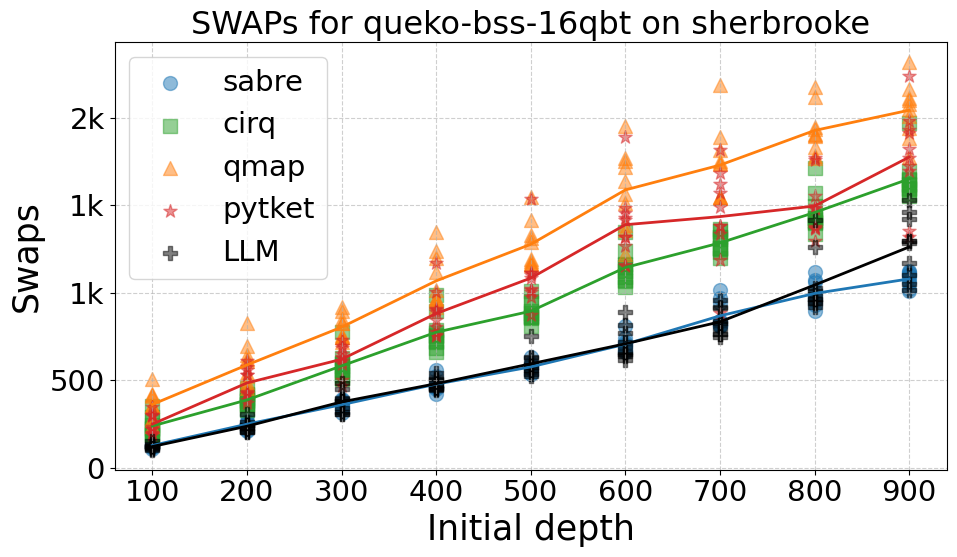

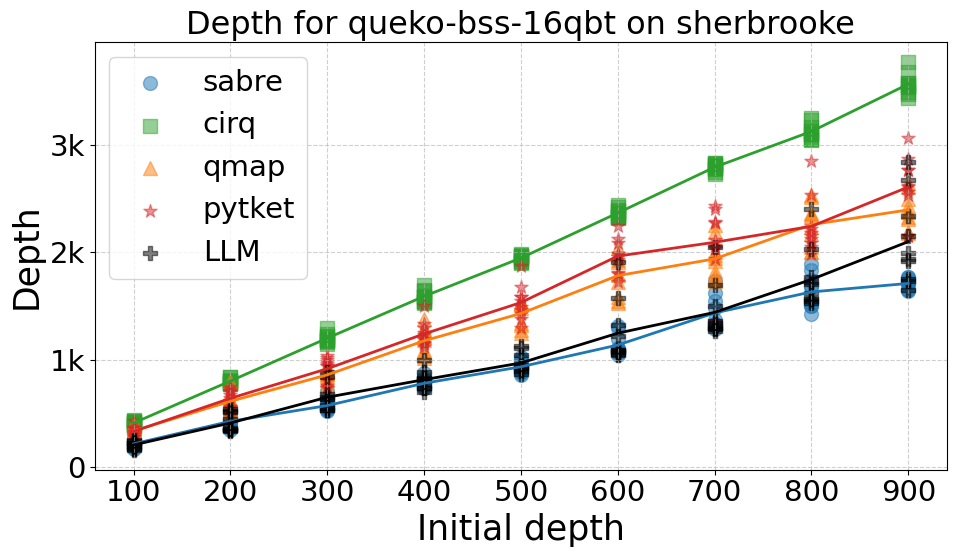

In [25]:
import os
import sys
import matplotlib.pyplot as plt
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-16qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"./baselines/results/{BENCHMARK}/sabre.csv",
    "cirq": f"./baselines/results/{BENCHMARK}/cirq.csv",
    "qmap": f"./baselines/results/{BENCHMARK}/qmap.csv",
    "pytket": f"./baselines/results/{BENCHMARK}/pytket.csv",
    "LLM" : f"/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/init_mapping_llm_queko-bss-16qbt_ibm_sherbrooke_trivial.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path) if name in ["LLM"] else group_by_initial_depth_baseline(
            path, backend=plot_backend, init_mapping_method="default")
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

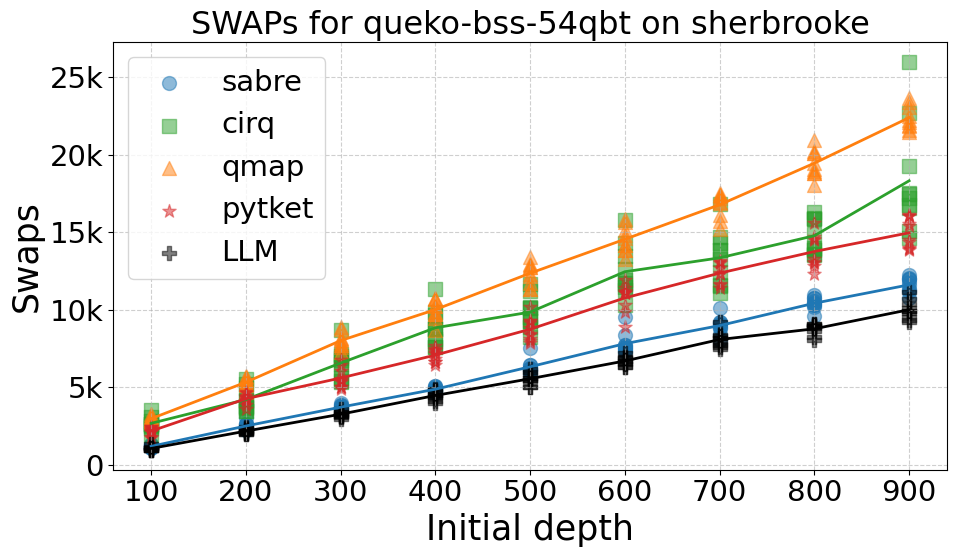

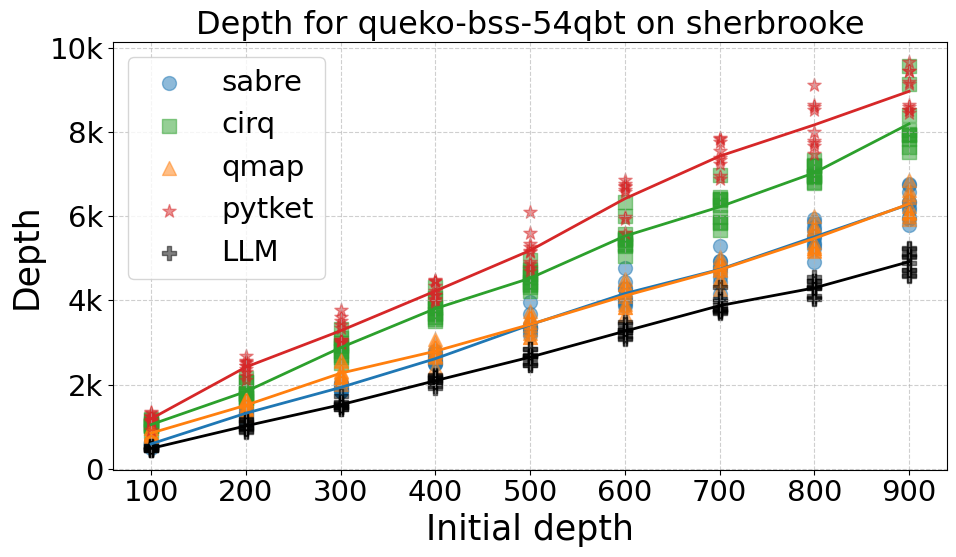

In [27]:
import os
import sys
import matplotlib.pyplot as plt
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-54qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"./baselines/results/{BENCHMARK}/sabre.csv",
    "cirq": f"./baselines/results/{BENCHMARK}/cirq.csv",
    "qmap": f"./baselines/results/{BENCHMARK}/qmap.csv",
    "pytket": f"./baselines/results/{BENCHMARK}/pytket.csv",
    "LLM" : f"/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/init_mapping_llm_queko-bss-54qbt_ibm_sherbrooke_trivial.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path) if name in ["LLM"] else group_by_initial_depth_baseline(
            path, backend=plot_backend, init_mapping_method="default")
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

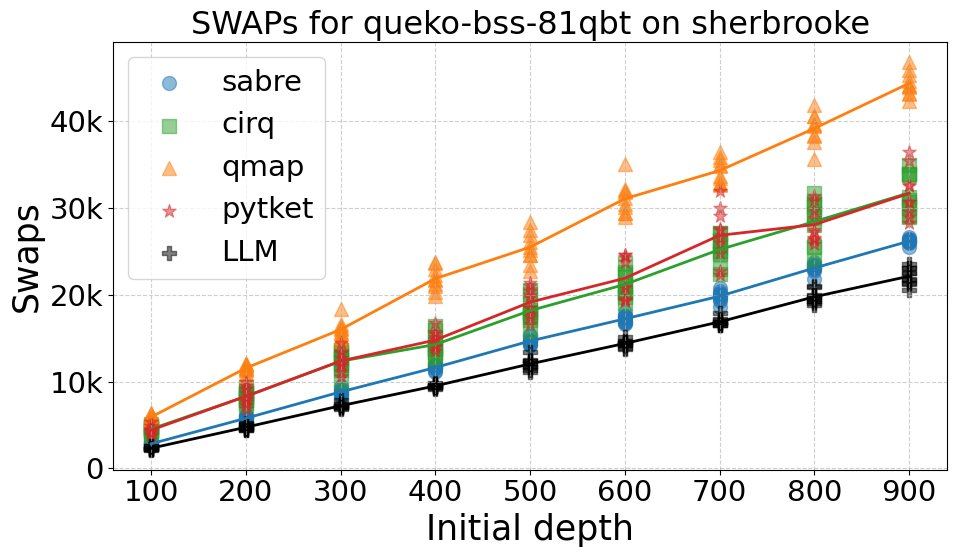

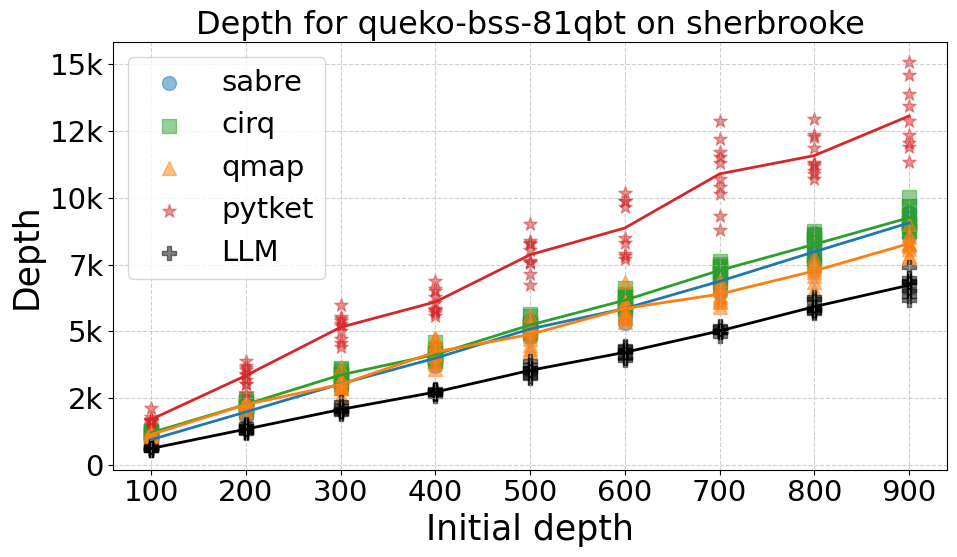

In [29]:
import os
import sys
import matplotlib.pyplot as plt
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-81qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"./baselines/results/{BENCHMARK}/sabre.csv",
    "cirq": f"./baselines/results/{BENCHMARK}/cirq.csv",
    "qmap": f"./baselines/results/{BENCHMARK}/qmap.csv",
    "pytket": f"./baselines/results/{BENCHMARK}/pytket.csv",
    "LLM" : f"/home/jmsb00nd/Documents/auto-heuristics/autoheuristics_results/init_mapping_llm_queko-bss-81qbt_ibm_sherbrooke_trivial.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path) if name in ["LLM"] else group_by_initial_depth_baseline(
            path, backend=plot_backend, init_mapping_method="default")
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

## QUEKO 16QBT
| Method | Swap Improvement (%) | Depth Improvement (%) |
| :--- | :---: | :---: |
| sabre | -3.99 | -8.41 |
| cirq | 32.80 | 46.21 |
| qmap | 50.34 | 25.10 |
| pytket | 39.94 | 29.41 |
| EOH | 22.22 | 20.83 |
| Funsearch | 11.66 | 11.31 |
| Reevo | 12.13 | 12.43 |
| mcts | -5.52 | -5.50 |
| Qlosure | -2.22 | -8.59 |
| **Average** | **17.04%** | **13.64%** |

---

## QUEKO 54QBT
| Method | Swap Improvement (%) | Depth Improvement (%) |
| :--- | :---: | :---: |
| sabre | 12.84 | 21.06 |
| cirq | 45.01 | 41.23 |
| qmap | 55.26 | 23.26 |
| EOH | 12.33 | 10.80 |
| Funsearch | 14.20 | 12.84 |
| Reevo | 10.04 | 8.95 |
| mcts | 5.69 | 10.14 |
| Qlosure | 2.59 | 12.27 |
| **Average** | **19.75%** | **17.57%** |

---

## QUEKO 81QBT
| Method | Swap Improvement (%) | Depth Improvement (%) |
| :--- | :---: | :---: |
| sabre | 16.17 | 28.14 |
| cirq | 33.60 | 31.71 |
| qmap | 52.53 | 25.67 |
| EOH | 10.49 | 9.52 |
| Funsearch | 18.73 | 28.70 |
| Reevo | 14.97 | 13.96 |
| mcts | 6.90 | 7.42 |
| Qlosure | 10.36 | 33.02 |
| **Average** | **20.47%** | **22.27%** |

---